In [1]:
import pandas as pd

cols = [
    "id", "t0", "tc", "mz1", "mz2",
    "s1", "s1x", "s1y", "s1z",
    "s2", "s2x", "s2y", "s2z",
    "lambda1", "lambda2",
    "z", "distMpc",
    "ra", "decl",
    "psi", "inc", "phi0",
    "snrET_Opt", "snrCE_Opt",
    "type"
]

df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)

bbh_df = df[df["type"] == 3]


# Optional: save result
bbh_df.to_csv("bbh_parameters.txt", sep=" ", index=False)

print(bbh_df.head())

/tmp/ipykernel_11415/2017370559.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)


          id                t0                tc         mz1         mz2  \
32771  32771  1001247662.44053  1001247669.88242  100.279488   85.251263   
32784  32784  1001247893.63311  1001247957.43047   38.629408   28.254866   
32805  32805  1001248621.12121  1001248628.32812  152.503365  104.892501   
32825  32825  1001249243.20422  1001249245.65209  311.852633  205.409477   
32841  32841  1001249933.81903  1001249965.58051   41.308904   37.320676   

           s1       s1x       s1y       s1z      s2  ...       z      distMpc  \
32771  0.1235  0.013183 -0.029315  0.119244  0.0334  ...  3.4914   31190.1931   
32784  0.1867  0.064595  0.170024  0.042145  0.1618  ...  1.1966    8472.6809   
32805  0.7407 -0.359227  0.175262 -0.623599  0.0774  ...  2.5415   21305.2232   
32825  0.1567  0.100325 -0.029027  0.116821  0.0772  ...  9.7118  102537.1595   
32841  0.1639 -0.114497 -0.094921  0.068875  0.2355  ...  1.2609    9037.5106   

             ra      decl       psi       inc      phi0 

/tmp/ipykernel_11415/2017370559.py:15: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)


In [2]:
import pandas as pd

# Load file
df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)

# Filter BBHs
bbh_df = df[df["type"] == 3]

#select only the distance and redshift columns
bbh_dist_redshift = bbh_df[["distMpc", "z"]]

# Select only the mass columns
bbh_masses = df[df["type"] == 3][["mz1", "mz2"]]
# Remove decimals by truncation
bbh_masses = bbh_masses.astype(int)

# save result
bbh_df.to_csv("bbh1_parameters.txt", sep=" ", index=False)
bbh_masses.to_csv("bbh1_masses.txt", sep=" ", index=False)
bbh_dist_redshift.to_csv("bbh1_dist_redshift.txt", sep=" ", index=False)

/tmp/ipykernel_11415/881260442.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)


In [10]:
import pandas as pd

df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)

# Filter BBHs
df = df[df["type"] == 3]

df["m1_source"] = df["mz1"] / (1 + df["z"])
df["m1_source"] = df["m1_source"].astype(int)
df["m2_source"] = df["mz2"] / (1 + df["z"])
df["m2_source"] = df["m2_source"].astype(int)

df[["m1_source", "m2_source"]].to_csv(
    "bbh_masses_source.txt", sep=" ", index=False
)

/tmp/ipykernel_22527/2223503669.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)


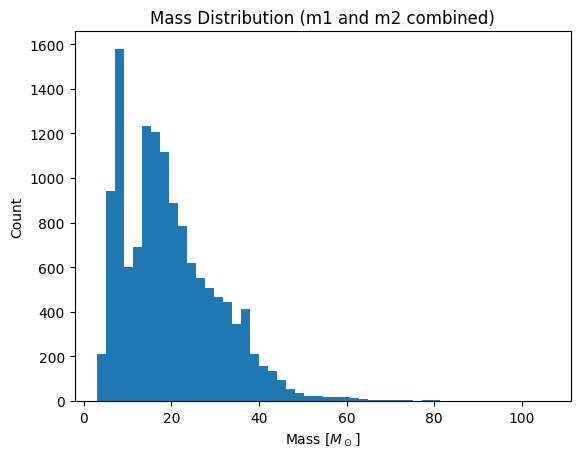

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load your file
data = np.loadtxt("bbh_masses_source.txt", skiprows=1)

m1 = data[:, 0]
m2 = data[:, 1]

# Combine both masses
masses = np.concatenate([m1, m2])

plt.figure()
plt.hist(masses, bins=50)
plt.xlabel("Mass [$M_\\odot$]")
plt.ylabel("Count")
plt.title("Mass Distribution (m1 and m2 combined)")
plt.show()

In [15]:
import numpy as np

data = np.loadtxt("bbh_masses_source.txt", skiprows=1)

m1 = data[:, 0]
m2 = data[:, 1]

# Combine all component masses
masses = np.concatenate([m1, m2])

# Compute percentiles
p1 = np.percentile(masses, 1)
p10 = np.percentile(masses, 10)
p20 = np.percentile(masses, 20)
p50 = np.percentile(masses, 50)  # Median
p80 = np.percentile(masses, 80)
p90 = np.percentile(masses, 90)
p99 = np.percentile(masses, 99)
p999 = np.percentile(masses, 99.9)
p9999 = np.percentile(masses, 99.99)

print("1% mass:", p1)
print("10% mass:", p10)
print("20% mass:", p20)
print("50% mass:", p50)
print("80% mass:", p80)
print("90% mass:", p90)
print("99% mass:", p99)
print("99.9% mass:", p999)
print("99.99% mass:", p9999)

1% mass: 5.0
10% mass: 8.0
20% mass: 9.0
50% mass: 18.0
80% mass: 29.0
90% mass: 35.0
99% mass: 53.0
99.9% mass: 79.0
99.99% mass: 97.96529999999439


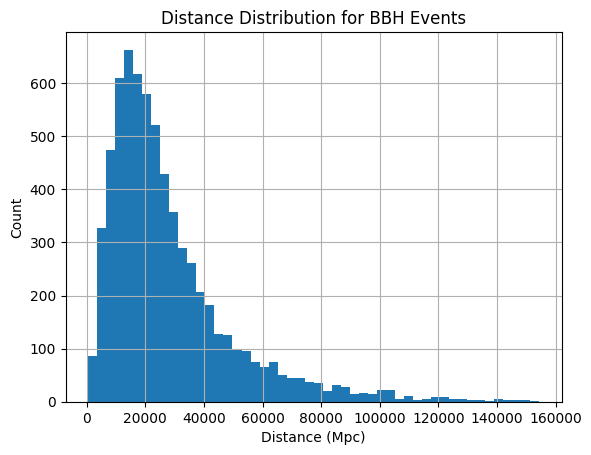

0.01% distance: 528.844262
0.1% distance: 1170.5959028
1% distance: 3138.183832
10% distance: 8356.00856
20% distance: 12057.486340000001
50% distance: 22076.282
80% distance: 39918.41588
90% distance: 55874.01712000002
99% distance: 110454.65731200008
99.9% distance: 146236.14461320135
99.99% distance: 153560.19074319955


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load your file
data = np.loadtxt("bbh1_dist_redshift.txt", skiprows=1)

distances = data[:, 0]
#redshifts = data[:, 1]  
plt.figure()
plt.hist(distances, bins=50)
plt.xlabel("Distance (Mpc)")
plt.ylabel("Count")
plt.title("Distance Distribution for BBH Events")
plt.grid()
plt.show()
p001 = np.percentile(distances, 0.01)
p01 = np.percentile(distances, 0.1)
p1 = np.percentile(distances, 1)
p10 = np.percentile(distances, 10)
p20 = np.percentile(distances, 20)            
p50 = np.percentile(distances, 50)  # Median
p80 = np.percentile(distances, 80)
p90 = np.percentile(distances, 90)
p99 = np.percentile(distances, 99)
p999 = np.percentile(distances, 99.9)
p9999 = np.percentile(distances, 99.99)


print("0.01% distance:", p001)
print("0.1% distance:", p01)
print("1% distance:", p1)
print("10% distance:", p10)
print("20% distance:", p20)
print("50% distance:", p50)
print("80% distance:", p80)
print("90% distance:", p90)
print("99% distance:", p99)
print("99.9% distance:", p999)
print("99.99% distance:", p9999)
